In [1]:
import os
from pathlib import Path


def _resolve_partition_root():
    cwd = Path(os.getcwd()).resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "primary_script").exists() and (p / "intermediate").exists():
            return p
        candidate = p / "technical_review" / "submission_partition_draft"
        if (candidate / "primary_script").exists():
            return candidate
    raise RuntimeError("Could not locate submission_partition_draft root")


REPO_ROOT = _resolve_partition_root()
PBMC_INTERMEDIATE = REPO_ROOT / "intermediate" / "pbmc"


In [6]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import scvi
import torch
import warnings
import leidenalg as la
import anndata
from matplotlib import pyplot as plt
from matplotlib.pyplot import rc_context
from scvi.autotune import ModelTuner
from ray import tune
import glob
import re
import csv
import itertools

In [7]:
PBMC_INTERMEDIATE.mkdir(parents=True, exist_ok=True)
(REPO_ROOT / "intermediate" / "adipose").mkdir(parents=True, exist_ok=True)


mkdir: cannot create directory ‘/media/MPEdge16/MM137/sc/py/py_out/pbmc’: File exists
mkdir: cannot create directory ‘/media/MPEdge16/MM137/sc/py/py_out/adipose’: File exists


In [8]:
warnings.filterwarnings('ignore')
sc.set_figure_params(dpi=200)
plt.rcParams['figure.figsize'] = [3,3]

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [10]:
os.chdir(str(REPO_ROOT / 'intermediate'))


In [11]:
matching_files = glob.glob(os.path.join(str(REPO_ROOT / "primary_dependents" / "cellranger_h5"), "**/*.h5"), recursive=True)
regex = re.compile(r"MM-[1-8]\b")
pbmc_gex = [x for x in matching_files if regex.search(x)]
def sort_key(file):
    match = re.search(r"MM-(\d+)", file)
    return int(match.group(1)) if match else float('inf') # Uses infinity for files that don't match
pbmc_gex = sorted(pbmc_gex, key=sort_key)
pbmc_gex


['/media/MPEdge16/MM137/sc/10x_cloud_dl/10872-MM-1/filtered_feature_bc_matrix.h5',
 '/media/MPEdge16/MM137/sc/10x_cloud_dl/10872-MM-2/filtered_feature_bc_matrix.h5',
 '/media/MPEdge16/MM137/sc/10x_cloud_dl/10872-MM-3/filtered_feature_bc_matrix.h5',
 '/media/MPEdge16/MM137/sc/10x_cloud_dl/10872-MM-4/filtered_feature_bc_matrix.h5',
 '/media/MPEdge16/MM137/sc/10x_cloud_dl/10872-MM-5/filtered_feature_bc_matrix.h5',
 '/media/MPEdge16/MM137/sc/10x_cloud_dl/10872-MM-6/filtered_feature_bc_matrix.h5',
 '/media/MPEdge16/MM137/sc/10x_cloud_dl/10872-MM-7/filtered_feature_bc_matrix.h5',
 '/media/MPEdge16/MM137/sc/10x_cloud_dl/10872-MM-8/filtered_feature_bc_matrix.h5']

In [12]:
matching_files = glob.glob(os.path.join(str(REPO_ROOT / "primary_dependents" / "souporcell"), "**/*clusters.tsv"), recursive=True)
regex = re.compile(r"MM-[0-9]+")
fil_dict = zip(matching_files, [regex.search(x).group() for x in matching_files])
pbmc_soc = [x for x, y in fil_dict if y in ['MM-' + str(x) for x in range(1, 9)]]
def sort_key(file):
    match = re.search(r"MM-(\d+)", file)
    return int(match.group(1)) if match else float('inf') # Uses infinity for files that don't match
pbmc_soc = sorted(pbmc_soc, key=sort_key)
pbmc_soc


['/media/MPEdge16/KoetheShare/Mashayekhi_10x/SADIE/souporcell_outs/10872-MM-1_soc/clusters.tsv',
 '/media/MPEdge16/KoetheShare/Mashayekhi_10x/SADIE/souporcell_outs/10872-MM-2_soc/clusters.tsv',
 '/media/MPEdge16/KoetheShare/Mashayekhi_10x/SADIE/souporcell_outs/10872-MM-3_soc/clusters.tsv',
 '/media/MPEdge16/KoetheShare/Mashayekhi_10x/SADIE/souporcell_outs/10872-MM-4_soc/clusters.tsv',
 '/media/MPEdge16/KoetheShare/Mashayekhi_10x/SADIE/souporcell_outs/10872-MM-5_soc/clusters.tsv',
 '/media/MPEdge16/KoetheShare/Mashayekhi_10x/SADIE/souporcell_outs/10872-MM-6_soc/clusters.tsv',
 '/media/MPEdge16/KoetheShare/Mashayekhi_10x/SADIE/souporcell_outs/10872-MM-7_soc/clusters.tsv',
 '/media/MPEdge16/KoetheShare/Mashayekhi_10x/SADIE/souporcell_outs/10872-MM-8_soc/clusters.tsv']

In [13]:
matching_files = glob.glob(os.path.join(str(REPO_ROOT / "primary_dependents" / "snp_correlation"), "**/*.txt"), recursive=True)
regex = re.compile(r"(?!MM137)MM[0-9]+")
fil_dict = zip(matching_files, [regex.search(x).group() for x in matching_files])
pbmc_snp = [x for x, y in fil_dict if y in ['MM' + str(x) for x in range(1, 9)]]
regex_num = re.compile(r'[0-9]+')
sort_key = [int(x) for x in [regex_num.search(x).group() for x in [x.group() for x in [regex.search(x) for x in pbmc_snp]]]]
pbmc_snp = [pbmc_snp[i] for i in np.argsort(sort_key)]


In [14]:
file_list = [[x,y,z] for x,y,z in zip(pbmc_gex, pbmc_soc, pbmc_snp)]
file_list

[['/media/MPEdge16/MM137/sc/10x_cloud_dl/10872-MM-1/filtered_feature_bc_matrix.h5',
  '/media/MPEdge16/KoetheShare/Mashayekhi_10x/SADIE/souporcell_outs/10872-MM-1_soc/clusters.tsv',
  '/media/MPEdge16/MM137/sc/snp_correlation/MM1/Genotype_ID_key.txt'],
 ['/media/MPEdge16/MM137/sc/10x_cloud_dl/10872-MM-2/filtered_feature_bc_matrix.h5',
  '/media/MPEdge16/KoetheShare/Mashayekhi_10x/SADIE/souporcell_outs/10872-MM-2_soc/clusters.tsv',
  '/media/MPEdge16/MM137/sc/snp_correlation/MM2/Genotype_ID_key.txt'],
 ['/media/MPEdge16/MM137/sc/10x_cloud_dl/10872-MM-3/filtered_feature_bc_matrix.h5',
  '/media/MPEdge16/KoetheShare/Mashayekhi_10x/SADIE/souporcell_outs/10872-MM-3_soc/clusters.tsv',
  '/media/MPEdge16/MM137/sc/snp_correlation/MM3/Genotype_ID_key.txt'],
 ['/media/MPEdge16/MM137/sc/10x_cloud_dl/10872-MM-4/filtered_feature_bc_matrix.h5',
  '/media/MPEdge16/KoetheShare/Mashayekhi_10x/SADIE/souporcell_outs/10872-MM-4_soc/clusters.tsv',
  '/media/MPEdge16/MM137/sc/snp_correlation/MM4/Genotype_ID

In [15]:
def load_gex(list_of_lists):
    gex_file = list_of_lists[0]
    soc_file = list_of_lists[1]
    snp_file = list_of_lists[2]
    match = re.compile(r"MM-[0-9]+")
    lane = match.search(gex_file).group()
    adata = sc.read_10x_h5(gex_file)
    adata.obs['lane'] = lane
    soc = pd.read_csv(soc_file, sep='\t', index_col=0)
    adata = adata[adata.obs.index.isin(soc.index)]
    status_dict = dict(zip(soc.index, soc['status']))
    adata.obs['souporcell_status'] = adata.obs.index.map(status_dict)
    assignment_dict = dict(zip(soc.index, soc['assignment']))
    adata.obs['souporcell_assignment'] = adata.obs.index.map(assignment_dict)
    snp_read = pd.read_csv(snp_file, sep='\t')
    snp_read = snp_read[~np.isnan(snp_read['Correlation'])]
    sadie_match = re.compile(r'Sadie-[0-9]+')
    snp_read['Genotype_ID'] = [sadie_match.search(x).group() for x in snp_read['Genotype_ID']]
    simple_snp_dict = dict(zip(snp_read['Cluster_ID'],snp_read['Genotype_ID']))
    key_permutations = list(itertools.permutations(simple_snp_dict.keys(), 2))
    soc_dict = {}
    for key_perm in key_permutations:
        key_str = '/'.join(key_perm)
        value_str = '/'.join(str(simple_snp_dict[k]) for k in key_perm)
        soc_dict[key_str] = value_str
    soc_dict_full = simple_snp_dict.copy()
    soc_dict_full.update(soc_dict)
    adata.obs['study_id'] = adata.obs['souporcell_assignment'].map(soc_dict_full)
    match_2 = re.compile(r'[0-9]+')
    lane_num = match_2.search(lane).group()
    match_3 = re.compile(r'[A-Z]+')
    bc_oligo = [match_3.search(x).group() for x in adata.obs_names]
    adj_bc = [x + '-' + y for x,y in zip(bc_oligo, lane_num * len(bc_oligo))]
    adata.obs['barcode_2'] = adj_bc
    adata = adata[adata.obs['souporcell_status']!='unassigned']
    adata.obs_names = adata.obs['barcode_2']
    adata.obs_names_make_unique()
    adata.obs.index = adata.obs_names
    adata.var_names_make_unique()
    return adata

In [16]:
adatas = [load_gex(x) for x in file_list]

In [17]:
lane_layout = pd.read_csv(str(REPO_ROOT / "primary_dependents" / "MM148_key.csv"), index_col=0)
lane_layout = lane_layout[lane_layout['Tissue type'] == 'PBMCs']
pbmc_lanes = lane_layout['Multiplex ID'].unique()
for i in pbmc_lanes:
    subset_layout = lane_layout[lane_layout['Multiplex ID'] == i]
    subset_layout_dict = dict(zip(subset_layout['Sample ID'], subset_layout['Study day']))
    key_permutations = list(itertools.permutations(subset_layout_dict.keys(), 2))
    pid_lane_dict = {}
    for key_perm in key_permutations:
        key_str = '/'.join(key_perm)
        value_str = '/'.join(str(subset_layout_dict[k]) for k in key_perm)
        pid_lane_dict[key_str] = value_str
    pid_lane_dict_tmp = subset_layout_dict.copy()
    pid_lane_dict_tmp.update(pid_lane_dict)
    tmp_list = [(x, y) for x, y in pid_lane_dict_tmp.items()]
    tmp_df = pd.DataFrame(tmp_list, columns=['study_id', 'sd'])
    tmp_df['lane'] = str(i)
    if i == pbmc_lanes[0]:
        pid_lane_df = tmp_df.copy()
    else:
        pid_lane_df = pd.concat([pid_lane_df, tmp_df])
pid_lane_df['pid_lane'] = [x + '_' + y for x, y in zip(pid_lane_df['study_id'], pid_lane_df['lane'])]


In [18]:
def add_sd(ad, sd_map_dict = pid_lane_df):
    if len(ad.obs['lane'].unique())==1:
        subset_map = pid_lane_df[pid_lane_df['lane']==re.sub('MM-','',ad.obs['lane'][0])]
        ad.obs['map_sd'] = [x+'_'+y for x,y in zip([re.sub('-','',x).upper() for x in ad.obs['study_id']], [re.sub('MM-','',x) for x in ad.obs['lane']])]
        ad.obs['study_day'] = ad.obs['map_sd'].map(dict(zip(subset_map['pid_lane'],subset_map['sd'])))
        return ad
    else:
        return 'failed to execute'

In [19]:
adatas = [add_sd(x) for x in adatas]

In [20]:
adata = sc.concat(adatas)

In [21]:
adata.obs

,lane,souporcell_status,souporcell_assignment,study_id,barcode_2,map_sd,study_day
barcode_2,,,,,,,
AAACCTGAGAAGATTC-1,MM-1,singlet,1,Sadie-018,AAACCTGAGAAGATTC-1,SADIE018_1,SD1
AAACCTGAGACCTAGG-1,MM-1,singlet,1,Sadie-018,AAACCTGAGACCTAGG-1,SADIE018_1,SD1
AAACCTGAGAGACGAA-1,MM-1,singlet,1,Sadie-018,AAACCTGAGAGACGAA-1,SADIE018_1,SD1
AAACCTGAGAGAGCTC-1,MM-1,doublet,1/2,Sadie-018/Sadie-016,AAACCTGAGAGAGCTC-1,SADIE018/SADIE016_1,SD1/SD1
AAACCTGAGAGCCCAA-1,MM-1,singlet,0,Sadie-011,AAACCTGAGAGCCCAA-1,SADIE011_1,SD1
...,...,...,...,...,...,...,...
TTTGTCATCTACCAGA-8,MM-8,doublet,2/1,Sadie-038/Sadie-016,TTTGTCATCTACCAGA-8,SADIE038/SADIE016_8,SD3/SD2
TTTGTCATCTATCCTA-8,MM-8,singlet,0,Sadie-036,TTTGTCATCTATCCTA-8,SADIE036_8,SD3
TTTGTCATCTGATACG-8,MM-8,singlet,2,Sadie-038,TTTGTCATCTGATACG-8,SADIE038_8,SD3


In [22]:
adata_soup_singlet = adata[adata.obs['souporcell_status'] == 'singlet']
soup_bcs = adata_soup_singlet.obs["barcode_2"].astype(str)

adata_singlet = sc.read_h5ad(str(PBMC_INTERMEDIATE / 'pbmc_int.h5ad'))
singlet_bcs = set(adata_singlet.obs["barcode_2"].astype(str).dropna())
keep_mask = soup_bcs.isin(singlet_bcs)
adata_soup_singlet = adata_soup_singlet[keep_mask].copy()
assert adata_soup_singlet.obs["barcode_2"].astype(str).isin(singlet_bcs).any()


In [23]:
adata_soup_doublet = adata[adata.obs['souporcell_status']=='doublet']
assert not adata_soup_doublet.obs["barcode_2"].astype(str).isin(singlet_bcs).any()
# pbmc singlet + souporcell doublets
adata_concat = sc.concat([adata_soup_singlet, adata_soup_doublet])
# ensure obs_names set correctly
adata_concat.obs_names = pd.Index(adata_concat.obs["barcode_2"], dtype="string")
assert np.all(adata_concat.X.data == adata_concat.X.data.astype(np.int32))
adata = adata_concat.copy()
del adata_concat # ensure all is in order

In [24]:
sc.pp.filter_cells(adata, min_genes = 200)
sc.pp.filter_genes(adata, min_cells = 10)
adata.var['MT'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=["MT"], inplace=True, percent_top=[20], log1p=True)
adata = adata[adata.obs.pct_counts_MT <= 10]

In [25]:
adata.layers['counts'] = adata.X.copy()

In [26]:
sc.pp.normalize_total(adata, target_sum = 1e4)
sc.pp.log1p(adata)
adata.raw = adata

In [27]:
sc.pp.highly_variable_genes(adata, n_top_genes=5000, subset = False, layer = 'counts', 
                            flavor = "seurat_v3", batch_key="lane")

In [28]:
adata_var = adata.var
csv_data = pd.read_csv(str(REPO_ROOT / 'primary_dependents' / 'EXCLUDE_XY_TCR_IG.csv'), header=None)

positions = np.where(adata.var_names.isin(csv_data[0]))[0]
adata.var.iloc[positions, adata.var.columns.get_loc('highly_variable')] = False
adata.var.loc[adata.var.index == "TRAV1-2", "highly_variable"] = True # force TRAV1-2 to be hvg; MAIT marker
adata.var['highly_variable'].value_counts()
adata


AnnData object with n_obs × n_vars = 360350 × 25076
    obs: 'lane', 'souporcell_status', 'souporcell_assignment', 'study_id', 'barcode_2', 'map_sd', 'study_day', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_MT', 'log1p_total_counts_MT', 'pct_counts_MT'
    var: 'n_cells', 'MT', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'log1p', 'hvg'
    layers: 'counts'

In [29]:
model_cls = scvi.model.SCVI
model_cls.setup_anndata(adata = adata, layer = "counts", batch_key = 'lane', 
                        categorical_covariate_keys=['study_id'], 
                        continuous_covariate_keys=['pct_counts_MT', 'total_counts'])
tuner = ModelTuner(model_cls)

In [30]:
tuner.info()

ModelTuner registry for SCVI

                  Tunable hyperparameters                  
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃      Hyperparameter      ┃ Default value ┃    Source    ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│         n_hidden         │      128      │     VAE      │
│         n_latent         │      10       │     VAE      │
│         n_layers         │       1       │     VAE      │
│       dropout_rate       │      0.1      │     VAE      │
│        dispersion        │     gene      │     VAE      │
│     log_variational      │     True      │     VAE      │
│     gene_likelihood      │     zinb      │     VAE      │
│   latent_distribution    │    normal     │     VAE      │
│    encode_covariates     │     False     │     VAE      │
│ deeply_inject_covariates │     True      │     VAE      │
│      use_batch_norm      │     both      │     VAE      │
│      use_layer_norm      │     none      │     VAE      │
│  use_observed_lib_size   │     True      │     VAE      │
│      var_activation      │     None      │     VAE      │
│        optimizer         │     Adam      │ TrainingPlan │
│            lr            │     0.001     │ TrainingPlan │
│       weight_decay       │     1e-06     │ TrainingPlan │
│           eps            │     0.01      │ TrainingPlan │
│    n_steps_kl_warmup     │     None      │ TrainingPlan │
│    n_epochs_kl_warmup    │      400      │ TrainingPlan │
│   reduce_lr_on_plateau   │     False     │ TrainingPlan │
│        lr_factor         │      0.6      │ TrainingPlan │
│       lr_patience        │      30       │ TrainingPlan │
│       lr_threshold       │      0.0      │ TrainingPlan │
│          lr_min          │       0       │ TrainingPlan │
│      max_kl_weight       │      1.0      │ TrainingPlan │
│      min_kl_weight       │      0.0      │ TrainingPlan │
│        batch_size        │      128      │     SCVI     │
└──────────────────────────┴───────────────┴──────────────┘

       Available metrics        
┏━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃     Metric      ┃    Mode    ┃
┡━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ validation_loss │    min     │
└─────────────────┴────────────┘

                         Default search space                         
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Hyperparameter ┃ Sample function ┃  Arguments  ┃ Keyword arguments ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│    n_hidden    │     choice      │ [[64, 128]] │        {}         │
└────────────────┴─────────────────┴─────────────┴───────────────────┘

In [31]:
search_space = {
    "n_hidden": tune.choice([92, 128, 192, 256]),
    "n_latent": tune.choice([10, 20, 30, 40, 50, 60]),
    "n_layers": tune.choice([1, 2, 3]),
    "lr": tune.loguniform(1e-4, 1e-2),
    "gene_likelihood": tune.choice(["nb", "zinb"])}

In [32]:
results = tuner.fit(adata, metric="validation_loss",
                    resources = {'gpu': 1}, 
                    search_space = search_space,
                    num_samples = 100,
                    max_epochs = 20)

2026-05-04 10:45:57,486	INFO worker.py:1749 -- Started a local Ray instance.
2026-05-04 10:46:00,371	INFO tune.py:253 -- Initializing Ray automatically. For cluster usage or custom Ray initialization, call `ray.init(...)` before `Tuner(...)`.
2026-05-04 10:46:00,376	INFO tune.py:614 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949
(raylet) [2026-05-04 10:46:06,395 E 2059949 2059986] (raylet) file_system_monitor.cc:111: /tmp/ray/session_2026-05-04_10-45-53_342731_2058478 is over 95% full, available space: 46034554880; capacity: 1006450962432. Object creation will fail if spilling is required.
(_trainable pid=2062727) /media/MPEdge16/miniconda_ns/lib/python3.9/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.
(_trainable pid=

In [48]:
import ray
ray.shutdown()

In [54]:
import math
import re

def extract_from_path(path):
    m = re.search(
        r"gene_likelihood=([^,]+),lr=([^,]+),n_hidden=([^,]+),n_latent=([^,]+),n_layers=([^_]+)",
        path or ""
    )
    if not m:
        return {}
    return {
        "gene_likelihood": m.group(1),
        "lr": float(m.group(2)),
        "n_hidden": int(m.group(3)),
        "n_latent": int(m.group(4)),
        "n_layers": int(m.group(5)),
    }

records = []
for r in getattr(results, "results", []):
    loss = (getattr(r, "metrics", {}) or {}).get("validation_loss", math.inf)
    cfg = getattr(r, "config", None) or {}
    if not cfg:
        cfg = extract_from_path(getattr(r, "path", ""))

    records.append({
        "validation_loss": loss,
        "config": cfg,
        "path": getattr(r, "path", None),
        "result_obj": r,
    })

records = [x for x in records if math.isfinite(x["validation_loss"])]
records.sort(key=lambda x: x["validation_loss"])

best = records[0]
print("best validation_loss:", best["validation_loss"])
print("best config:", best["config"])
print("best path:", best["path"])

best validation_loss: 3870.331787109375
best config: {'n_hidden': 256, 'n_latent': 60, 'n_layers': 1, 'lr': 0.002349021772741661, 'gene_likelihood': 'zinb'}
best path: /media/MPEdge16/MM137/sc/py/scvi_log/autotune/2026-05-04_10-45-46_scvi/_trainable_072d56f7_76_gene_likelihood=zinb,lr=0.0023,n_hidden=256,n_latent=60,n_layers=1_2026-05-04_14-47-54


In [60]:
# after tuning
top_param = {'n_hidden': 256, 
'n_latent': 60, 
'n_layers': 1, 
'gene_likelihood': 'zinb', 
'lr': 0.002349021772741661}

In [61]:
scvi.model.SCVI.setup_anndata(adata = adata, layer = "counts", batch_key = 'lane', 
                              categorical_covariate_keys=['study_id'], 
                              continuous_covariate_keys=['pct_counts_MT', 'total_counts'])

In [63]:
model = scvi.model.SCVI(adata, n_hidden = top_param['n_hidden'], 
                        n_latent = top_param['n_latent'], 
                        n_layers = top_param['n_layers'], 
                        gene_likelihood = top_param['gene_likelihood'])
kwargs = {'lr': top_param['lr']}

In [64]:
model.train(max_epochs = 200, early_stopping = True, plan_kwargs = kwargs)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA RTX 4000 Ada Generation') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 200/200: 100%|██████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [2:51:53<00:00, 52.47s/it, v_num=1, train_loss_step=3.89e+3, train_loss_epoch=3.89e+3]

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 200/200: 100%|██████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [2:51:53<00:00, 51.57s/it, v_num=1, train_loss_step=3.89e+3, train_loss_epoch=3.89e+3]


In [65]:
y = model.history['reconstruction_loss_validation']['reconstruction_loss_validation'].min()

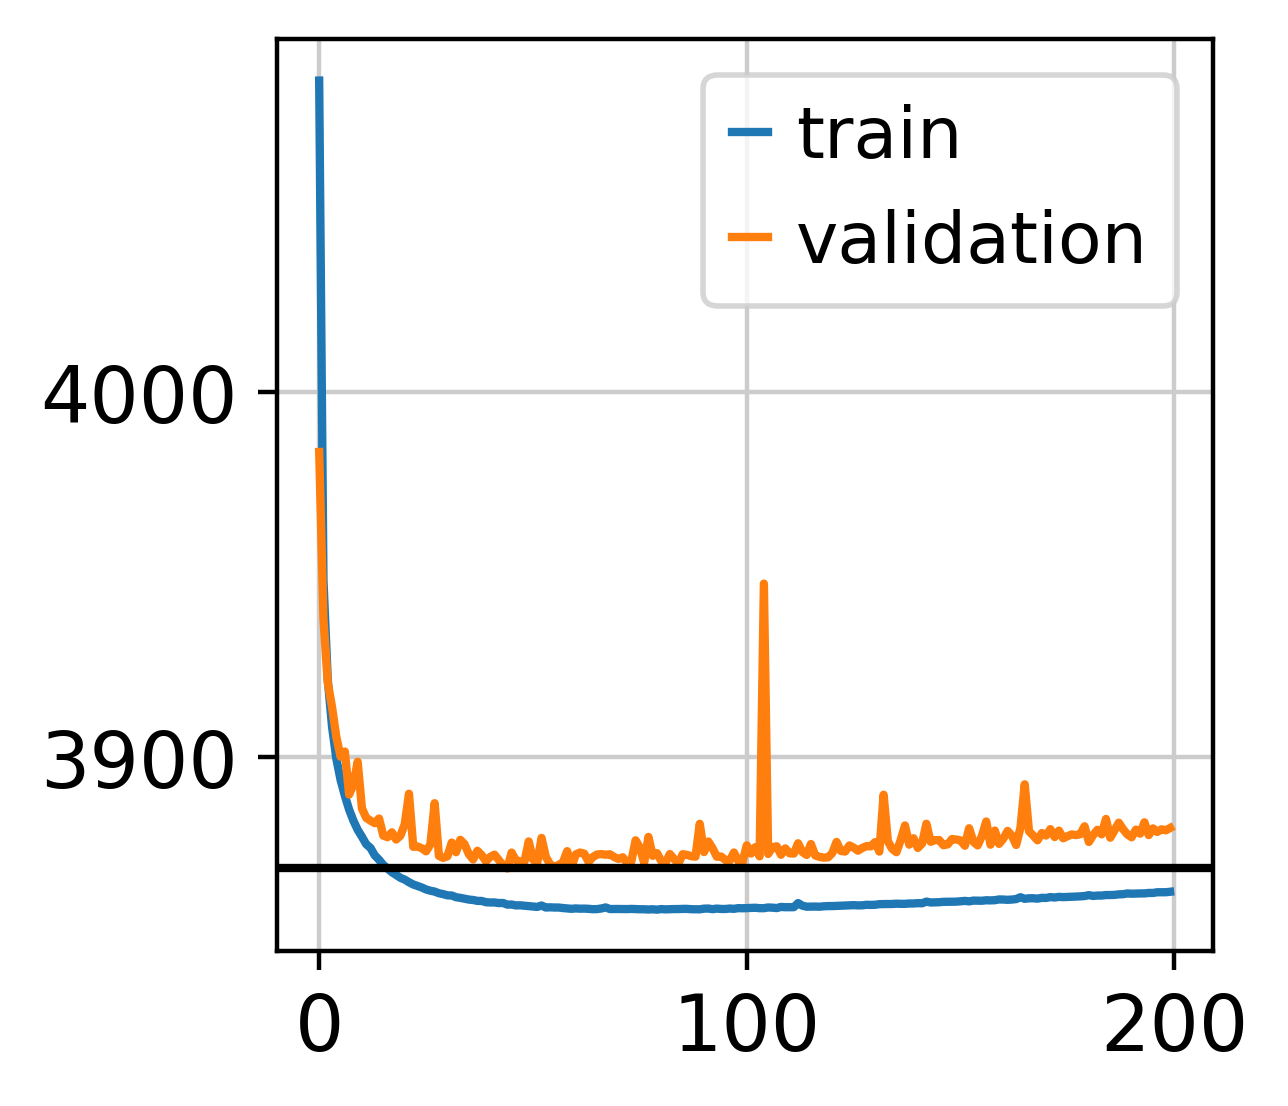

In [66]:
plt.plot(model.history['reconstruction_loss_train']['reconstruction_loss_train'], label='train')
plt.plot(model.history['reconstruction_loss_validation']['reconstruction_loss_validation'], label='validation')

plt.axhline(y, c = 'k')

plt.legend()
plt.show()

In [ ]:
model.save(str(PBMC_INTERMEDIATE / 'pbmc_scvi_integration_model_dbl'))


In [71]:
# ensure formatting before write
def fix_stringarray(df):
    """Convert StringDtype index and columns to object dtype."""
    if isinstance(df.index.dtype, pd.StringDtype):
        df.index = df.index.astype(str)
    for col in df.columns:
        if isinstance(df[col].dtype, pd.StringDtype):
            df[col] = df[col].astype(str)
    return df

# Fix obs and var
adata.obs = fix_stringarray(adata.obs)
adata.var = fix_stringarray(adata.var)

# Fix DataFrames in obsm
for key in list(adata.obsm.keys()):
    if isinstance(adata.obsm[key], pd.DataFrame):
        adata.obsm[key] = fix_stringarray(adata.obsm[key])

# Fix DataFrames in varm
for key in list(adata.varm.keys()):
    if isinstance(adata.varm[key], pd.DataFrame):
        adata.varm[key] = fix_stringarray(adata.varm[key])

adata.write_h5ad(str(PBMC_INTERMEDIATE / 'temp_pbmc_dbl.h5ad'))


In [ ]:
adata = sc.read_h5ad(str(PBMC_INTERMEDIATE / 'temp_pbmc_dbl.h5ad'))
model = scvi.model.SCVI.load(str(PBMC_INTERMEDIATE / 'pbmc_scvi_integration_model_dbl/'), adata)


In [12]:
adata.obsm['X_scVI'] = model.get_latent_representation()
scvi_norm_count = model.get_normalized_expression(library_size = 1e4)
adata.layers['scvi_normalized'] = scvi_norm_count

In [13]:
sc.pp.neighbors(adata, use_rep = 'X_scVI', random_state = 123)

In [14]:
sc.tl.leiden(adata, resolution = 3, key_added = 'overcluster')

In [15]:
sc.tl.umap(adata)

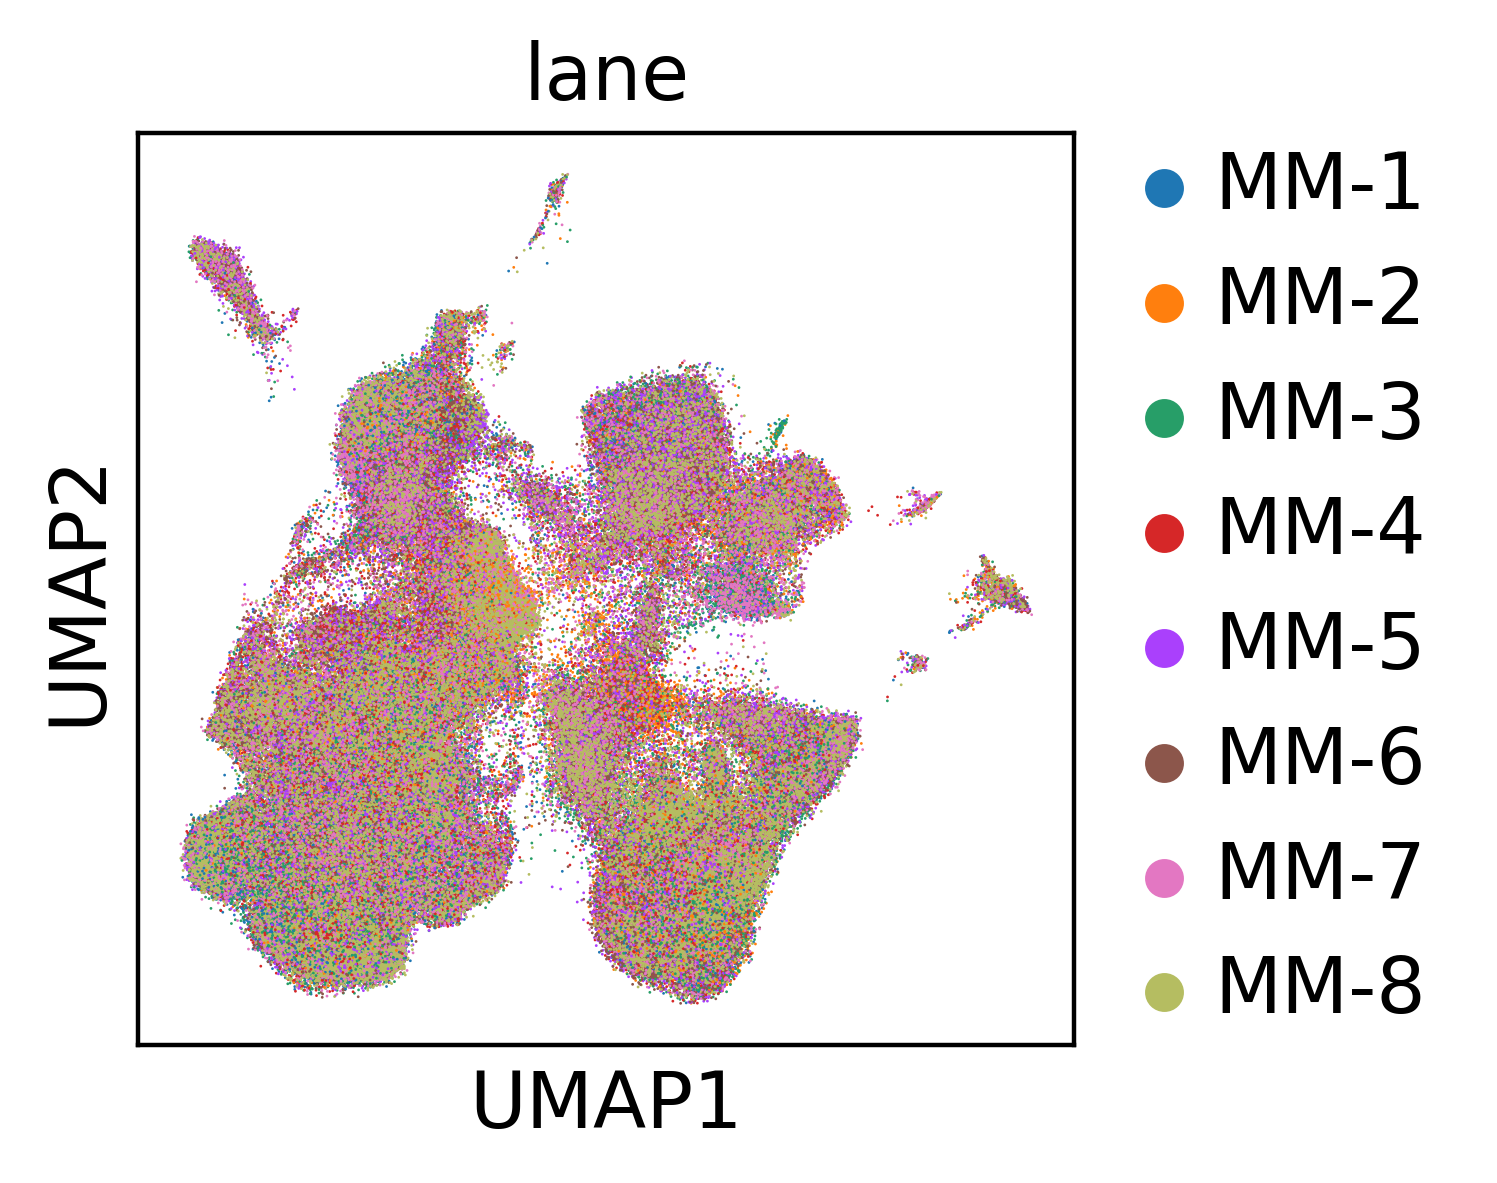

In [16]:
sc.pl.umap(adata, color = 'lane', size = 1, legend_fontsize = 'medium')

In [ ]:
sc.pl.umap(adata, color = 'study_id', size = 1, legend_fontsize = 'medium')

In [ ]:
sc.pl.umap(adata, color = 'study_day', size = 1, legend_fontsize = 'medium')

In [ ]:
plt.rcParams['figure.figsize'] = [6, 6] # width, height
sc.pl.umap(adata, color = 'souporcell_status', size = 1, legend_fontsize = 'medium')

In [ ]:
sc.set_figure_params(dpi=200)

sc.pl.umap(adata, color = ['CD3E','CD8A','CD79A','NKG7','CD14','FCGR3A','PF4','LYZ','TRAV1-2','TRGV9','MKI67','CD34','SELL','LEF1','BANK1','CD4'], size = 2, frameon = False, layer = 'scvi_normalized')

In [ ]:
plt.rcParams['figure.figsize'] = [7, 7]
sc.pl.umap(adata, color = 'overcluster', legend_loc = 'on data', size = 2, layer = 'scvi_normalized', legend_fontsize = 'small')

In [ ]:
sc.set_figure_params(dpi=100)
sc.pl.dotplot(adata, ['IL7R', 'TRAC', 'LEF1', 'CD3E', 'CD8A', 'CD8B', 'LINC02446', 'CD19', 
                      'MS4A1', 'CD79A', 'BANK1', 'IGHA2', 'TNFRSF17', 'HRASLS2', 'MKI67', 
                      'NKG7', 'XCL1', 'KLRD1', 'KLRF1', 'KLRB1', 'TRAV1-2', 'SLC4A10', 'FCGR3A', 
                      'CD14', 'NEAT1', 'LYZ', 'S100A9', 'ITM2C','JCHAIN','PLD4','SERPINF1', 
                      'PF4', 'HIST1H2AC', 'GP9', 'KIT', 'SOX4','CD34','FOXP3'], 
              groupby = 'overcluster', swap_axes = True, use_raw = True, standard_scale = 'var', dendrogram = False)

In [41]:
from pandas.errors import PerformanceWarning

# avoid plethora of message output
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        category=PerformanceWarning,
        module=r"scanpy\.tools\._rank_genes_groups"
    )
    sc.tl.rank_genes_groups(adata, groupby="overcluster", method="wilcoxon")

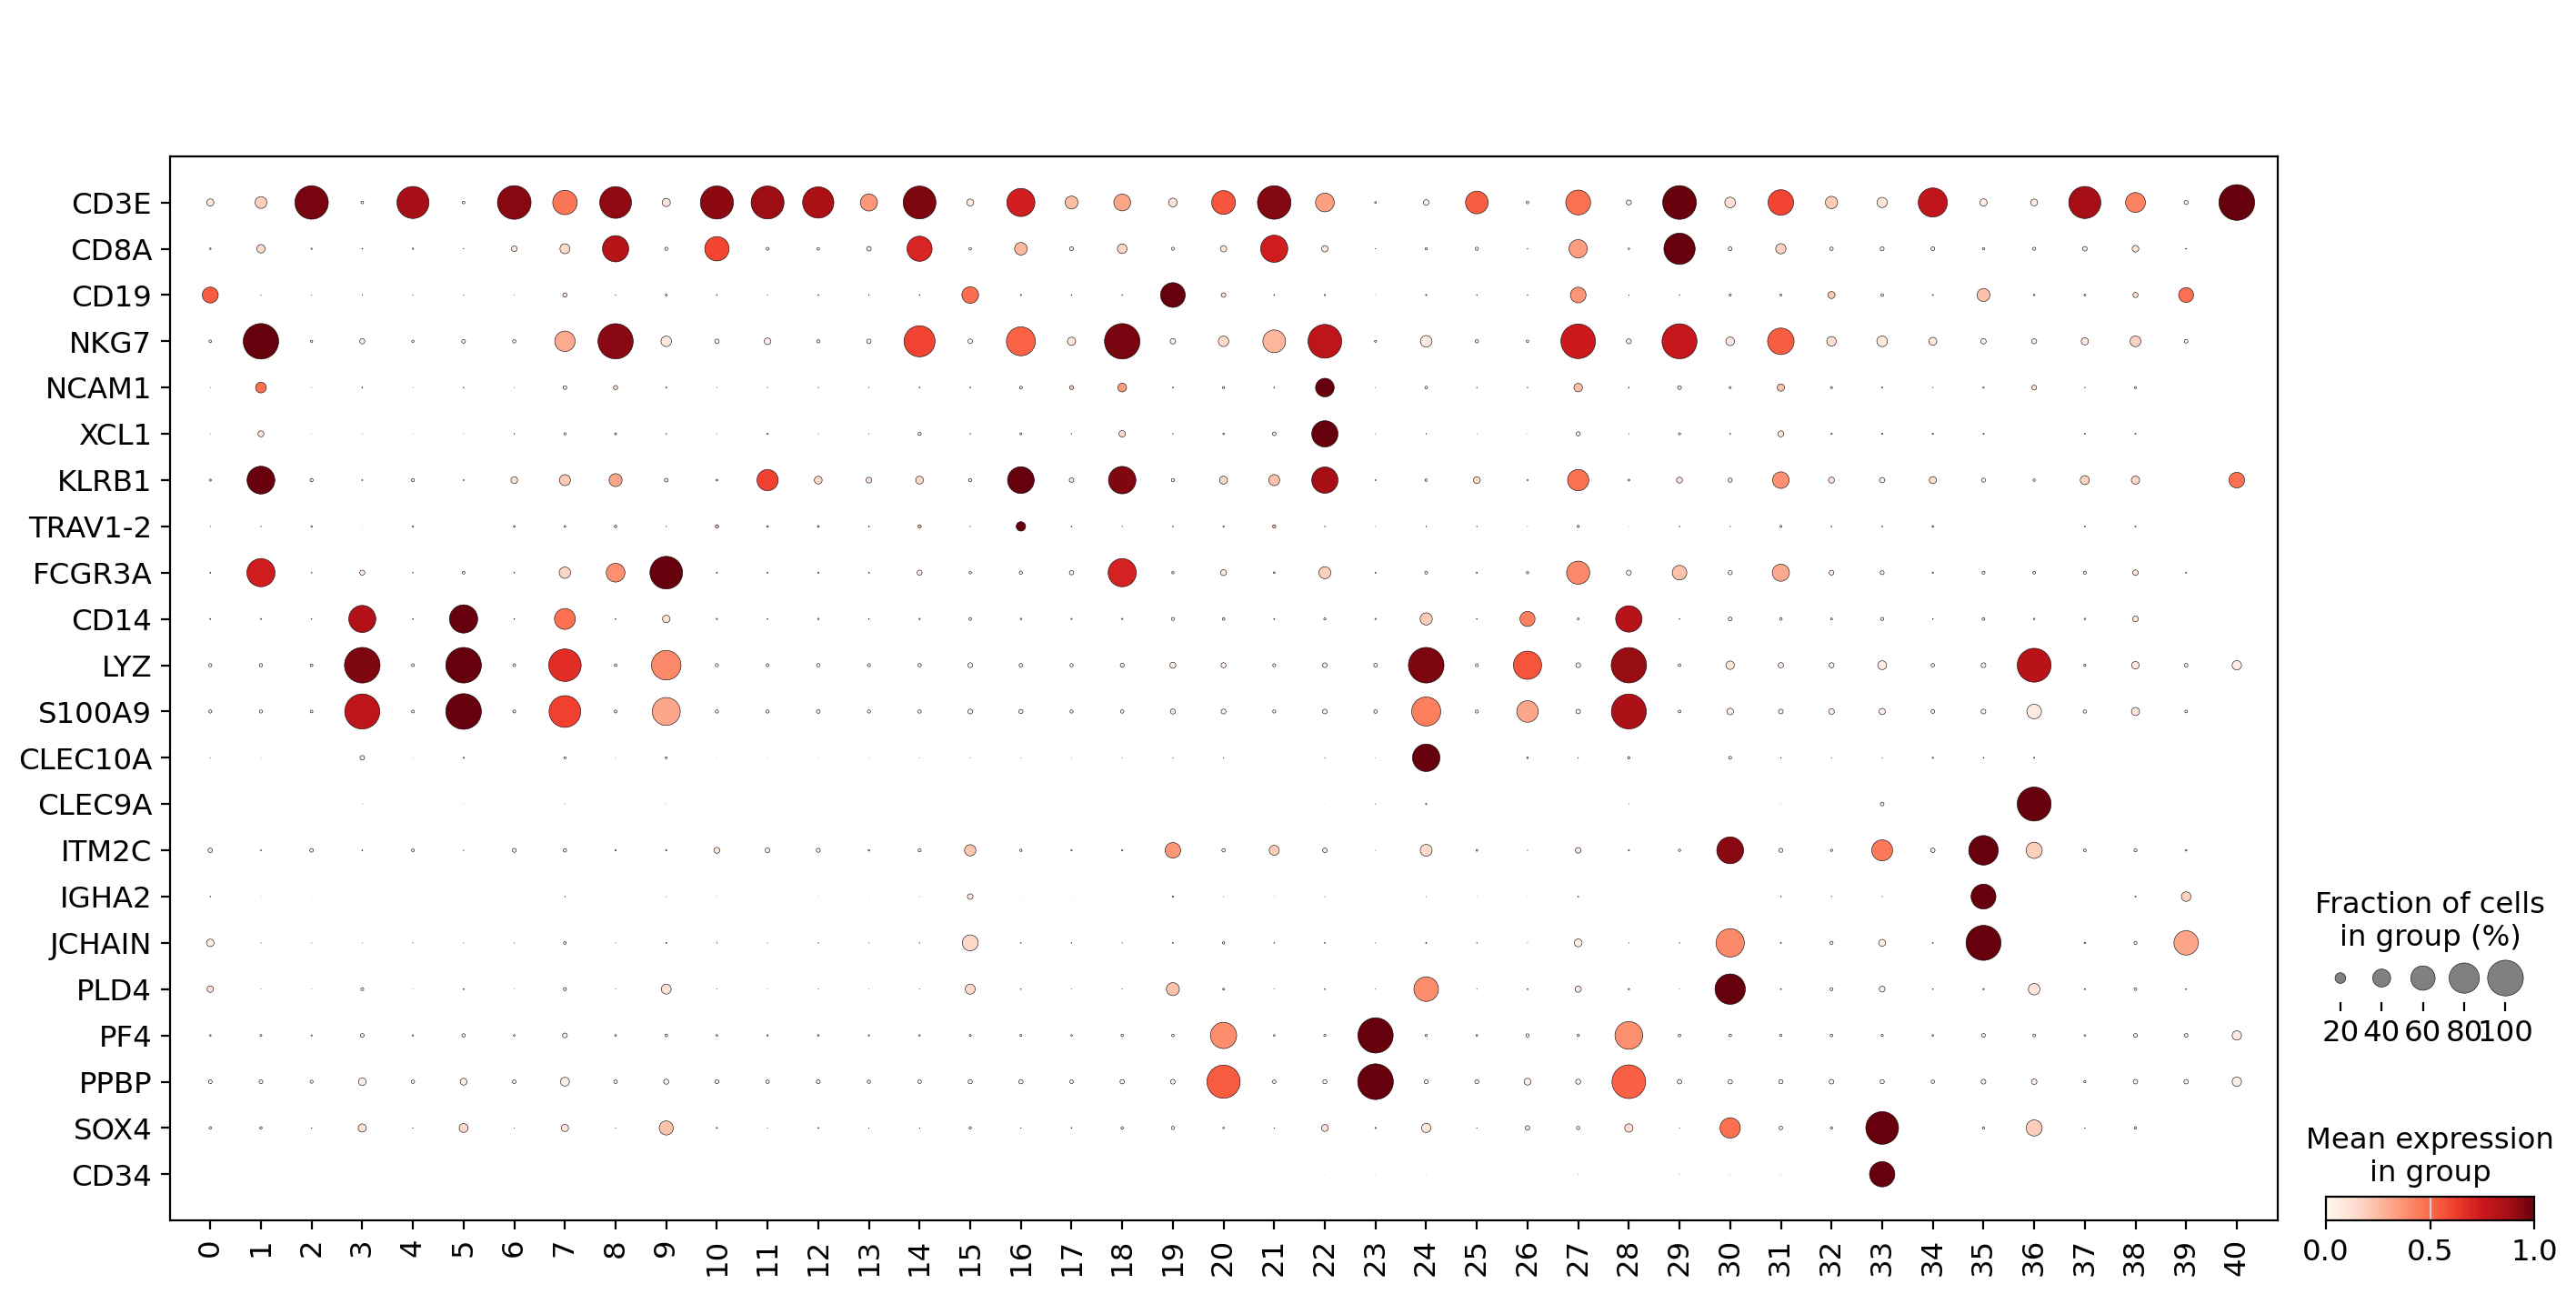

In [60]:
sc.set_figure_params(dpi=100)
sc.pl.dotplot(adata, ['CD3E','CD8A','CD19','NKG7','NCAM1','XCL1','KLRB1','TRAV1-2','FCGR3A', 
                      'CD14','LYZ','S100A9','CLEC10A','CLEC9A','ITM2C','IGHA2','JCHAIN','PLD4','PF4','PPBP','SOX4','CD34'], 
              groupby = 'overcluster', swap_axes = True, use_raw = True, standard_scale = 'var', dendrogram = False)

In [47]:
np.max(adata.obs['overcluster'].astype(int))

40

In [70]:
type_ref = {
    '0': '',
    '1': '',
    '2': '',
    '3': 'Myeloid',
    '4': '',
    '5': 'Myeloid',
    '6': '',
    '7': 'Myeloid_dbl',
    '8': '',
    '9': 'Myeloid',
    '10': '',
    '11': '',
    '12': '',
    '13': '',
    '14': '',
    '15': '',
    '16': '',
    '17': '',
    '18': '',
    '19': '',
    '20': '',
    '21': '',
    '22': '',
    '23': 'Platelet',
    '24': 'Myeloid',
    '25': '',
    '26': 'Myeloid',
    '27': '',
    '28': 'Myeloid',
    '29': '',
    '30': 'Myeloid', # pDC
    '31': '',
    '32': '',
    '33': '',
    '34': '',
    '35': '',
    '36': 'Myeloid', # cDC
    '37': '',
    '38': '',
    '39': '',
    '40': ''
}
adata.obs['cell_group'] = adata.obs['overcluster'].map(type_ref)
adata.obs['cell_group'] = [str(x) if x in ['Myeloid', 'Myeloid_dbl', 'Platelet'] else y for x, y in zip(adata.obs['cell_group'], adata.obs['overcluster'])]
adata.obs['solo_prediction'] = np.where(
    adata.obs['souporcell_status'].astype(str).eq('doublet'),
    'souporcell_doublet',
    'singlet'
)


In [ ]:
plt.rcParams['figure.figsize'] = [7, 7]
sc.pl.umap(adata, color = ['cell_group'], legend_loc = 'on data', size = 2, legend_fontsize = 10)

In [72]:
# write annotated pbmc-level doublet-inclusive, selectively annotated, post-integration object
adata.write_h5ad(str(PBMC_INTERMEDIATE / 'pbmc_int_dbl.h5ad'))


In [75]:
# write myeloid + myeloid-character doublets
adata_myl = adata[adata.obs['cell_group'].isin(['Myeloid', 'Myeloid_dbl', 'Platelet'])].copy()
adata_myl.write_h5ad(str(PBMC_INTERMEDIATE / 'pbmc_myeloid_dbl.h5ad')) # includes platelets
adata_myl.shape


(90189, 25076)